# 1. Getting Started with PA3Py

In this notebook, we will learn how to initialize `PA3Py`, run a growth simulation for an embryo, and plot the results.

In [1]:
import sys
import os
import matplotlib.pyplot as plt

# Add package path (if running from the local repository)
sys.path.insert(0, os.path.abspath('../../src'))
from pa3py import PA3Py
from pa3py import constants as c

## Initializing the Simulation

We load the simulation simply by passing the path of our HDF5 disk output to the main `PA3Py` class.

In [2]:
# Path to your TripodPy HDF5 data
data_path = '../../tests/test_data/run_smooth_a0.001_v10'

# Initialize the engine
sim = PA3Py(data_path)

[load_tripodpy_hdf5] Reading 100 snapshots from ../../tests/test_data/run_smooth_a0.001_v10...


## Running Growth

We will tell `PA3Py` to compute the growth for an embryo located at 3 AU, with an initial seed mass of $10^{-3} M_\oplus$.

In [3]:
# Embryos to simulate
embryos = [3.0]
# Execute the module
results = sim.run_growth(embryos, m_seed_me=1e-3)


-------------------------------------------------------------
  r [AU]  M_tot [ME]  M_iso [ME]  f_silicates[%]  f_H2O[%]
-------------------------------------------------------------
    3.00        9.016         9.02            50.0      50.0
-------------------------------------------------------------



## Plotting Mass Evolution

The `results` dictionary contains arrays where the first column is time (in seconds) and the second is the total mass of the embryo.

Instead of manually unpacking columns and calling matplotlib, PA3Py provides `plot_growth_curves`, which handles unit conversion, isolation-mass overlay, and works for any number of embryos.

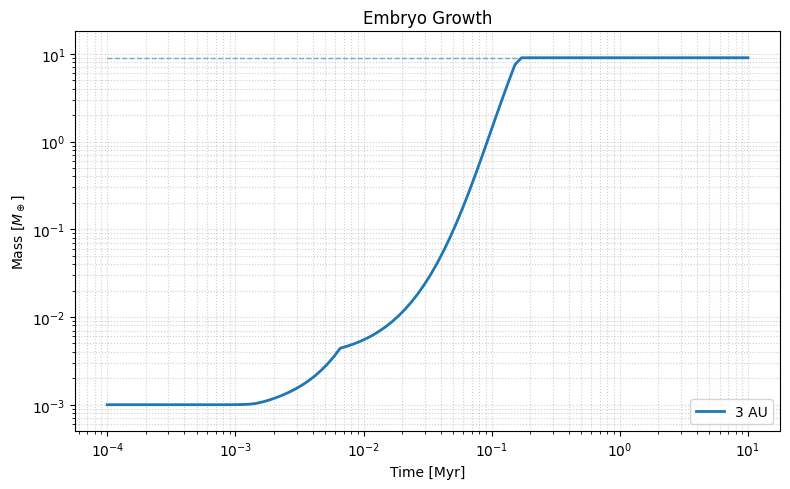

In [4]:
fig, ax = sim.plot_growth_curves(results)

## Water Mass Fraction

By default, PA3Py runs the classic `silicates` and `H2O` model by tracking the dynamic snowline position.
We can visualize this with `plot_species_fraction`, which works for any species tracked by the active composition model (default: `'H2O'`).

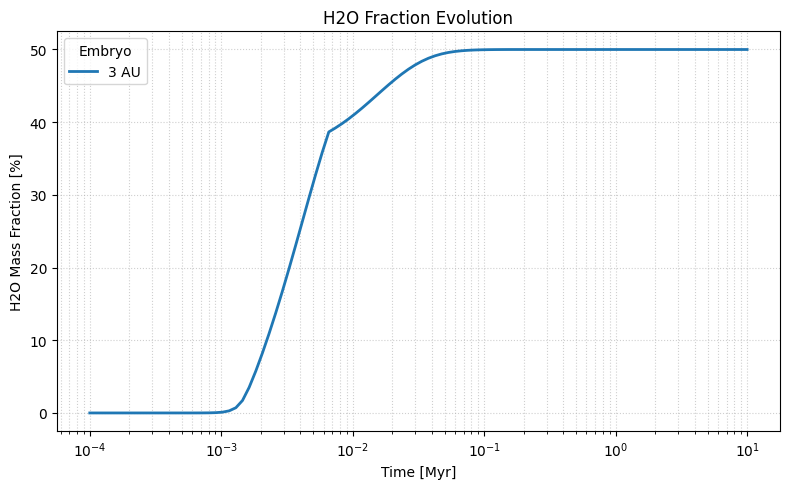

In [5]:
fig, ax = sim.plot_species_fraction(results, species='H2O')

## Bonus: Multiple Embryos at Once

`results` is a dictionary keyed by initial radius, so `run_growth` can simulate several embryos in one call. The plotting functions above accept the whole dictionary directly and overlay every trajectory automatically — no manual looping required.


-------------------------------------------------------------
  r [AU]  M_tot [ME]  M_iso [ME]  f_silicates[%]  f_H2O[%]
-------------------------------------------------------------
    1.00        0.020         3.96            71.4      28.6
    3.00        9.016         9.02            50.0      50.0
    5.00        0.202        13.23            50.2      49.8
    7.00        0.142        17.02            50.4      49.6
-------------------------------------------------------------



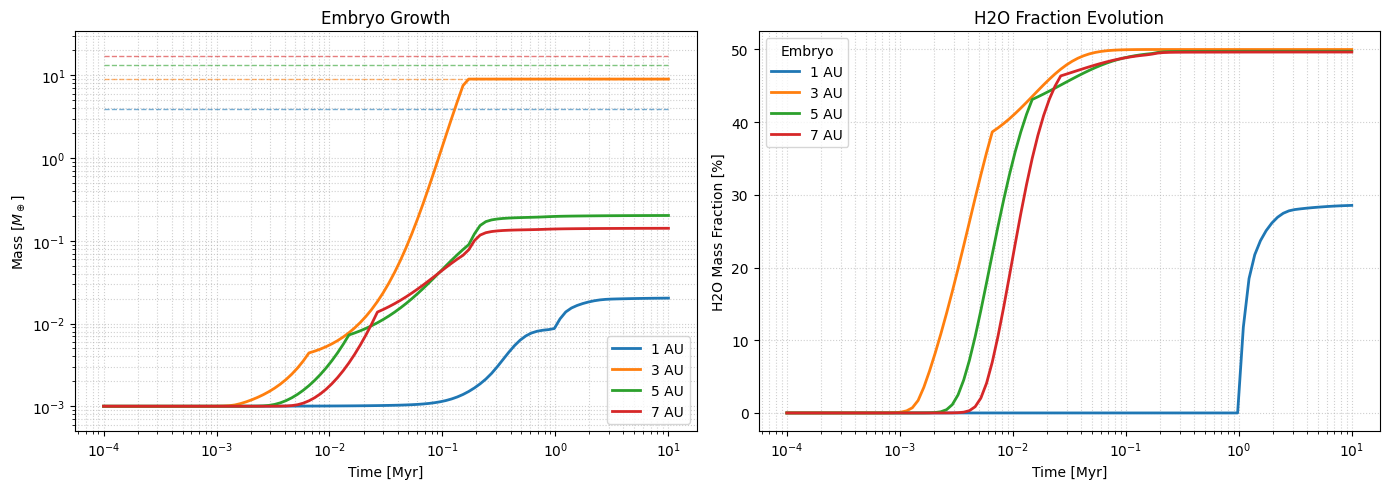

In [6]:
results_multi = sim.run_growth([1.0, 3.0, 5.0, 7.0], m_seed_me=1e-3)
fig, axes = sim.plot_growth_summary(results_multi, species='H2O')